## Property 3: Graded Membership

In [ ]:
# Setup
import pandas as pd
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import numpy as np
from collections import defaultdict
from matplotlib.ticker import MaxNLocator
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from matplotlib.gridspec import GridSpec
from matplotlib.cm import get_cmap
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Import Data

attributes_df  = pd.read_csv('01_catmemexp_attributestask_allmodels_processed_3.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding = "utf-8")
attributes_df['output_list_processed_nonoise'] = attributes_df['output_list_processed_nonoise'].apply(ast.literal_eval)

items_df = pd.read_csv('01_catmemexp_itemstask_allmodels_processed.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding="utf-8")
items_df['output_list_processed_nonoise'] = items_df['output_list_processed_nonoise'].apply(ast.literal_eval)

unique_attributes_df  = pd.read_csv('famres_scores_df.csv')
unique_attributes_df['attributes'] = unique_attributes_df['attributes'].apply(ast.literal_eval)
unique_attributes_df.head()

,model,category,item,attributes,attribute_scores,basic_measure,log_measure,frequency
0,Qwen2.5-7B-Instruct,Furniture,armchair,"[ergonomic, seating, spacious, portable, recli...","[np.int64(3), np.int64(5), np.int64(4), np.int...",44,12.727720,22
1,Qwen2.5-7B-Instruct,Furniture,bookshelf,"[sturdy, rectangular, horizontal, static, furn...","[np.int64(6), np.int64(9), np.int64(1), np.int...",52,12.727720,29
2,Qwen2.5-7B-Instruct,Furniture,bunk bed,"[sleeping, twin, elevated, space-saving, bed, ...","[np.int64(1), np.int64(1), np.int64(1), np.int...",28,5.455321,9
3,Qwen2.5-7B-Instruct,Furniture,cabinet,"[rectangular, storative, furniture, closed, fi...","[np.int64(9), np.int64(2), np.int64(5), np.int...",46,11.341425,8
4,Qwen2.5-7B-Instruct,Furniture,chair,"[sturdy, ergonomic, stable, seating, functiona...","[np.int64(6), np.int64(3), np.int64(3), np.int...",54,15.079095,30


In [ ]:
# Function to convert the attribute_scores column
def convert_attribute_scores(score_str):
    
    score_list = ast.literal_eval(score_str.replace('np.int64', ''))
    
    return [int(score) for score in score_list]

unique_attributes_df['attribute_scores'] = unique_attributes_df['attribute_scores'].apply(convert_attribute_scores)
unique_attributes_df['attribute_scores'][0]

[3, 5, 4, 3, 2, 4, 3, 13, 6, 1]

In [ ]:
# Preparing Data for Vectorization

unique_attributes_df['overall_cat_attributes'] = None
unique_attributes_df['item_vector_standard'] = None

unique_attributes_by_model = {}

for model, group in unique_attributes_df.groupby('model'):
    unique_attributes = set(attr for sublist in group['attributes'] for attr in sublist)
    unique_attributes_by_model[model] = list(unique_attributes)

for idx, row in unique_attributes_df.iterrows():
    model = row['model']

    overall_cat_attributes = unique_attributes_by_model[model]
    unique_attributes_df.at[idx, 'overall_cat_attributes'] = overall_cat_attributes

    feature_weights = []

    for attr in overall_cat_attributes:
        if attr in row['attributes']:
            
            attr_index = row['attributes'].index(attr)
            score = sum(row['attribute_scores'][attr_index]) if isinstance(row['attribute_scores'][attr_index], list) else row['attribute_scores'][attr_index]
            feature_weights.append(score)
        else:
            feature_weights.append(0)

    unique_attributes_df.at[idx, 'item_vector_standard'] = feature_weights

In [5]:
unique_attributes_df.head()

,model,category,item,attributes,attribute_scores,basic_measure,log_measure,frequency,overall_cat_attributes,item_vector_standard
0,Qwen2.5-7B-Instruct,Furniture,armchair,"[ergonomic, seating, spacious, portable, recli...","[3, 5, 4, 3, 2, 4, 3, 13, 6, 1]",44,12.727720,22,"[brakes, spicy, magazine-fed, green, loud, pro...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,Qwen2.5-7B-Instruct,Furniture,bookshelf,"[sturdy, rectangular, horizontal, static, furn...","[6, 9, 1, 1, 5, 1, 4, 2, 6, 2, 1, 1, 13]",52,12.727720,29,"[brakes, spicy, magazine-fed, green, loud, pro...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Qwen2.5-7B-Instruct,Furniture,bunk bed,"[sleeping, twin, elevated, space-saving, bed, ...","[1, 1, 1, 1, 1, 3, 1, 2, 13, 3, 1]",28,5.455321,9,"[brakes, spicy, magazine-fed, green, loud, pro...","[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."
3,Qwen2.5-7B-Instruct,Furniture,cabinet,"[rectangular, storative, furniture, closed, fi...","[9, 2, 5, 1, 1, 2, 1, 3, 6, 1, 2, 13]",46,11.341425,8,"[brakes, spicy, magazine-fed, green, loud, pro...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,Qwen2.5-7B-Instruct,Furniture,chair,"[sturdy, ergonomic, stable, seating, functiona...","[6, 3, 3, 5, 7, 1, 3, 1, 4, 13, 6, 2]",54,15.079095,30,"[brakes, spicy, magazine-fed, green, loud, pro...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [6]:
# Checking for any "empty" vectors

zero_vectors = unique_attributes_df[unique_attributes_df['item_vector_standard'].apply(lambda x: all(np.array(x) == 0))]

print(len(zero_vectors))

0


In [ ]:
# Vectorizing Items (UnSorted)

cosine_similarity_matrices = {}

for model in unique_attributes_df['model'].unique():
    model_df = unique_attributes_df[unique_attributes_df['model'] == model]

    vectors = np.array(model_df['item_vector_standard'].tolist())

    if vectors.shape[0] > 0 and np.all(vectors.sum(axis=1) > 0):
        
        normalized_vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
        
        similarity_matrix = cosine_similarity(normalized_vectors)
        cosine_similarity_matrices[model] = similarity_matrix
    else:
        print(f"No valid vectors for model: {model}. Skipping...")

In [ ]:
# Heatmap Visualization of Cosine Similarities (Sorted)

for model, similarity_matrix in cosine_similarity_matrices.items():
    model_df = unique_attributes_df[unique_attributes_df['model'] == model]
    
    plt.figure(figsize=(10, 8))
    heatmap = sns.heatmap(similarity_matrix, annot=False, cmap='coolwarm',
                          xticklabels=model_df['item'].values, 
                          yticklabels=model_df['item'].values,
                          cbar_kws={"shrink": .8})
    
    plt.title(f'{model}')
    plt.xlabel('Items')
    plt.ylabel('Items')
    
    cbar = heatmap.collections[0].colorbar
    cbar.set_label('Cosine Similarity')

    plt.xticks(fontsize=6)  
    plt.yticks(fontsize=6)  
    plt.show()


In [ ]:
# Using a sorted dataframe from now on (for plotting)
sorted_df = unique_attributes_df.sort_values(by=['model', 'category', 'frequency'], ascending=[True, True, False])
sorted_df.head()

,model,category,item,attributes,attribute_scores,basic_measure,log_measure,frequency,overall_cat_attributes,item_vector_standard
590,Meta-Llama-3.1-70B-Instruct,Clothing,boot,"[sturdy, heavy, thick, cushioned, rugged, buck...","[2, 1, 2, 2, 2, 1, 5, 8, 1, 12, 1, 1, 1, 2, 3,...",84,20.690412,30,"[intense, spicy, stem, hood, magazine-fed, hol...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, ..."
593,Meta-Llama-3.1-70B-Instruct,Clothing,jacket,"[fabric, price, filling, hood, warmth, adjusta...","[4, 3, 1, 1, 1, 8, 1, 1, 1, 2, 2, 1, 3, 2, 1, ...",69,19.409250,30,"[intense, spicy, stem, hood, magazine-fed, hol...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
594,Meta-Llama-3.1-70B-Instruct,Clothing,jean,"[blue, sturdy, trendy, rugged, durable, indigo...","[1, 2, 5, 2, 5, 1, 12, 2, 1, 1, 5, 5, 2, 1, 4,...",86,23.552613,30,"[intense, spicy, stem, hood, magazine-fed, hol...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
598,Meta-Llama-3.1-70B-Instruct,Clothing,shirt,"[fabric, button type, price, pattern, fit, sle...","[4, 1, 3, 1, 1, 1, 1, 2, 1, 3, 2, 3, 3, 2, 3, ...",47,14.046394,30,"[intense, spicy, stem, hood, magazine-fed, hol...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
599,Meta-Llama-3.1-70B-Instruct,Clothing,shoe,"[arch support, price, heel height, insulation,...","[1, 3, 1, 2, 3, 1, 2, 1, 3, 1, 1, 3, 3, 1, 2, ...",45,12.477778,30,"[intense, spicy, stem, hood, magazine-fed, hol...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
# Vectorizing Items (Sorted)

cosine_similarity_matrices = {}

for model in sorted_df['model'].unique():
    model_df = sorted_df[sorted_df ['model'] == model]

    vectors = np.array(model_df['item_vector_standard'].tolist())

    if vectors.shape[0] > 0 and np.all(vectors.sum(axis=1) > 0):
        
        normalized_vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
        
        similarity_matrix = cosine_similarity(normalized_vectors)
        cosine_similarity_matrices[model] = similarity_matrix
    else:
        print(f"No valid vectors for model: {model}. Skipping...")

In [ ]:
# Heatmap Visualization of Cosine Similarities (Sorted)

for model, similarity_matrix in cosine_similarity_matrices.items():
    model_df = sorted_df[sorted_df['model'] == model]
    
    plt.figure(figsize=(10, 8))
    heatmap = sns.heatmap(similarity_matrix, annot=False, cmap='coolwarm',
                          xticklabels=model_df['item'].values, 
                          yticklabels=model_df['item'].values,
                          cbar_kws={"shrink": .8})
    
    plt.title(f'{model}')
    plt.xlabel('Items')
    plt.ylabel('Items')

    cbar = heatmap.collections[0].colorbar
    cbar.set_label('Cosine Similarity')

    plt.xticks(fontsize=6)  
    plt.yticks(fontsize=6)  
    plt.show()


In [ ]:
# Dendrograms

for model_name, similarity_matrix in cosine_similarity_matrices.items():
    model_df = sorted_df[sorted_df['model'] == model_name]

    distance_matrix = 1 - similarity_matrix  

    linkage_matrix = linkage(distance_matrix, method='ward')

    sorted_items = model_df.sort_values(by=['category', 'frequency'], ascending=[True, False])

    sorted_labels = sorted_items['item'].values

    plt.figure(figsize=(10, 7))
    dendrogram(linkage_matrix,
               labels=sorted_labels, 
               leaf_rotation=90,
               leaf_font_size=8)
    plt.title(f'{model_name}')
    plt.xlabel('Items')
    plt.ylabel('Distance')
    plt.show()


In [ ]:
for model_name, similarity_matrix in cosine_similarity_matrices.items():
    model_df = sorted_df[sorted_df['model'] == model_name]

    if isinstance(similarity_matrix, np.ndarray):
        similarity_matrix = pd.DataFrame(similarity_matrix)

    distance_matrix = 1 - similarity_matrix.values 

    linkage_matrix = linkage(distance_matrix, method='ward')

    sorted_items = model_df.sort_values(by=['category', 'frequency'], ascending=[True, False])

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    plt.subplot(1, 2, 1)
    dn = dendrogram(linkage_matrix, labels=sorted_items['item'].values, 
                    leaf_rotation=90, leaf_font_size=6)

    plt.xlabel('Items')
    plt.ylabel('Distance')

    sorted_indices = leaves_list(linkage_matrix)

    ordered_similarity_matrix = pd.DataFrame(
        similarity_matrix.values[sorted_indices, :][:, sorted_indices],
        index=sorted_items['item'].iloc[sorted_indices].values,
        columns=sorted_items['item'].iloc[sorted_indices].values
    )

    plt.subplot(1, 2, 2)
    sns.heatmap(ordered_similarity_matrix, annot=False, cmap='coolwarm', 
                xticklabels=True, yticklabels=True)

    plt.xticks(fontsize=5)  
    plt.yticks(fontsize=5)  

    plt.xlabel('Items')
    plt.ylabel('Items')

    plt.suptitle(f'{model_name}', fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.96])  
    plt.show()


In [ ]:
# Heatmap and Dendrogram together

for model_name, similarity_matrix in cosine_similarity_matrices.items():
    model_df = sorted_df[sorted_df['model'] == model_name]

    if isinstance(similarity_matrix, np.ndarray):
        similarity_matrix = pd.DataFrame(similarity_matrix)

    distance_matrix = 1 - similarity_matrix.values  

    linkage_matrix = linkage(distance_matrix, method='ward')

    sorted_items = model_df.sort_values(by=['category', 'frequency'], ascending=[True, False])

    fig = plt.figure(figsize=(10, 8))  
    gs = GridSpec(1, 2, width_ratios=[1, 7]) 

    ax_dendro_row = fig.add_subplot(gs[:, 0])  
    dn_row = dendrogram(linkage_matrix, ax=ax_dendro_row, orientation='left',
                        labels=sorted_items['item'].values, leaf_rotation=0, leaf_font_size=8)

    sorted_row_indices = leaves_list(linkage_matrix)[::-1] 

    for line in ax_dendro_row.collections:
        line.set_edgecolor('black')
        line.set_linewidth(0.5)
    ax_dendro_row.set_title('', fontsize=10)
    ax_dendro_row.axis('off')

    ax_heatmap = fig.add_subplot(gs[0, 1])  
    
    ordered_similarity_matrix = pd.DataFrame(
        similarity_matrix.values[sorted_row_indices, :][:, sorted_row_indices],
        index=sorted_items['item'].iloc[sorted_row_indices].values,
        columns=sorted_items['item'].iloc[sorted_row_indices].values
    )

    heatmap = sns.heatmap(
        ordered_similarity_matrix, ax=ax_heatmap, annot=False, cmap='coolwarm',
        xticklabels=True, yticklabels=True, cbar_kws={"shrink": .8}
    )

    colorbar = heatmap.collections[0].colorbar
    colorbar.set_label('Cosine Similarity', rotation=270, labelpad=10, fontsize=10)

    ax_heatmap.set_title(f'{model_name}', fontsize=12)
    ax_heatmap.set_xlabel('Items', fontsize=7)
    ax_heatmap.set_ylabel('Items', fontsize=7)

    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)
    plt.tight_layout(rect=[0, 0, 1, 0.96]) 
    plt.show()


C:\Users\AS\AppData\Local\Temp\ipykernel_9524\2480882044.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = get_cmap('tab10').colors


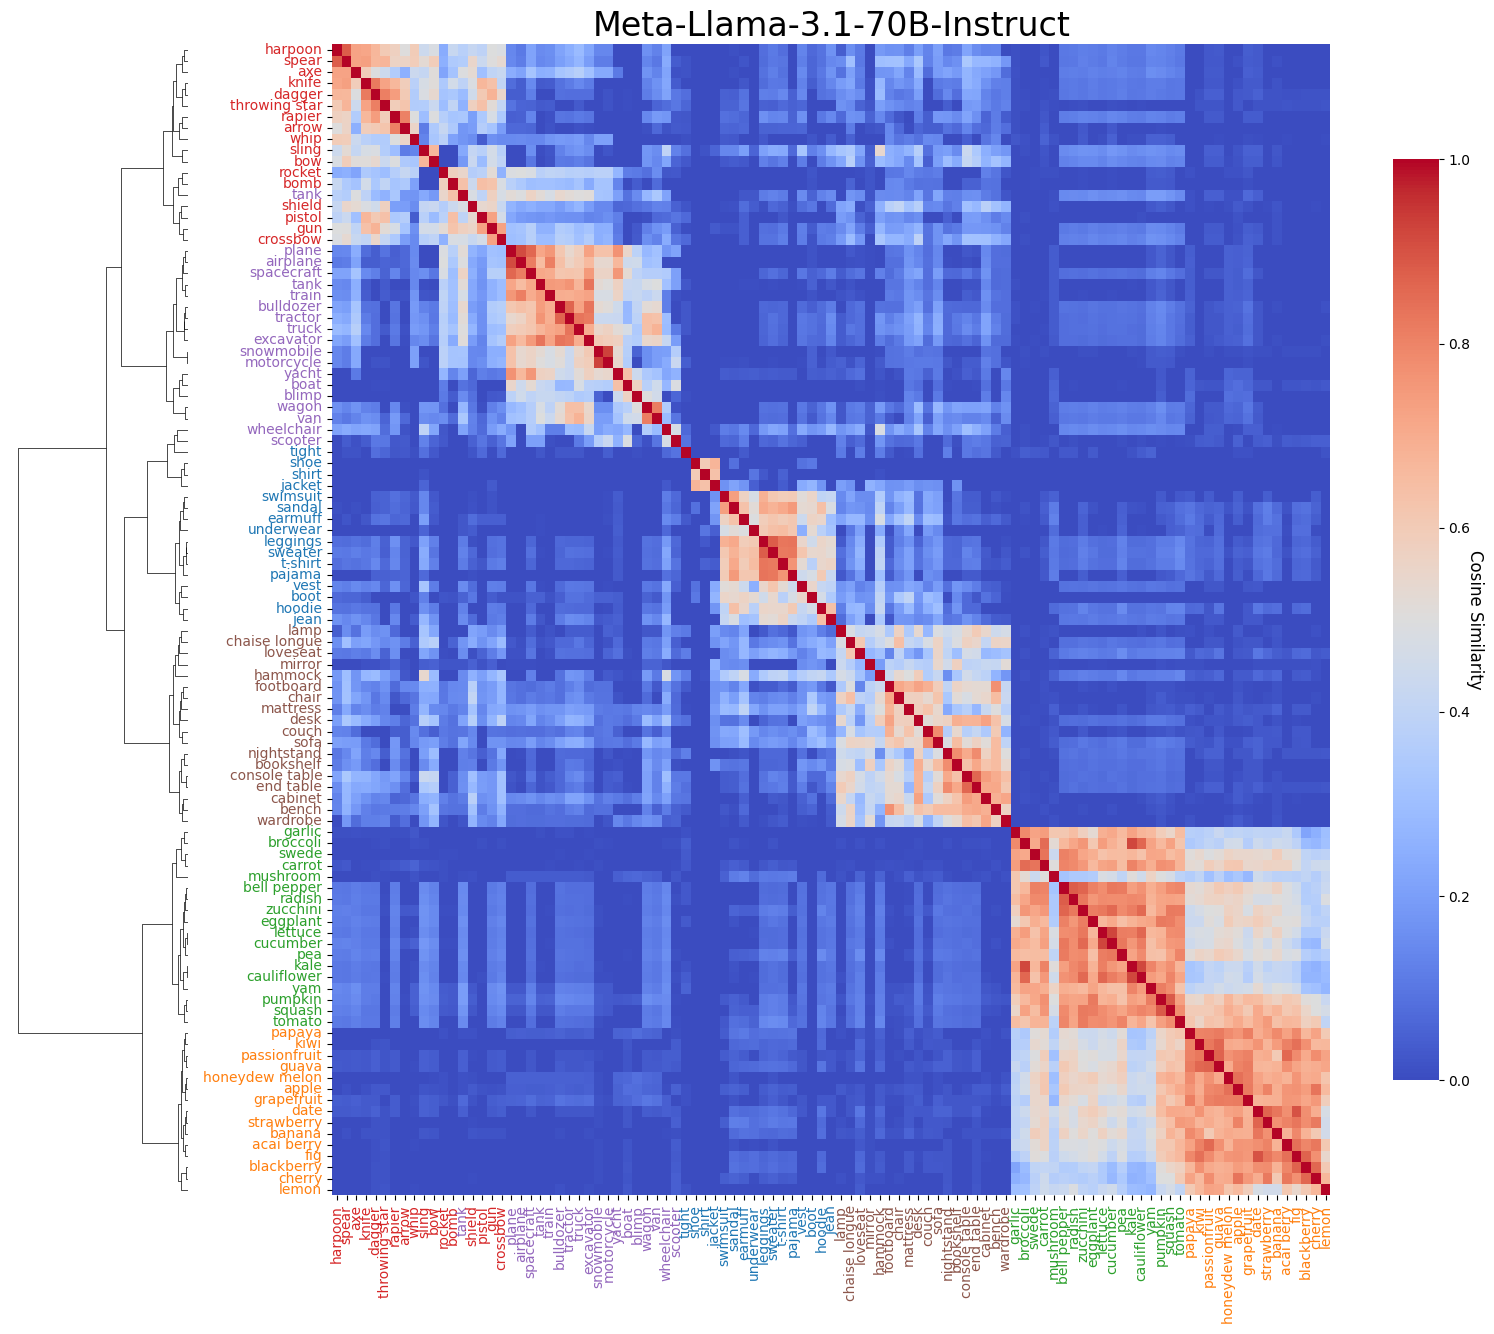

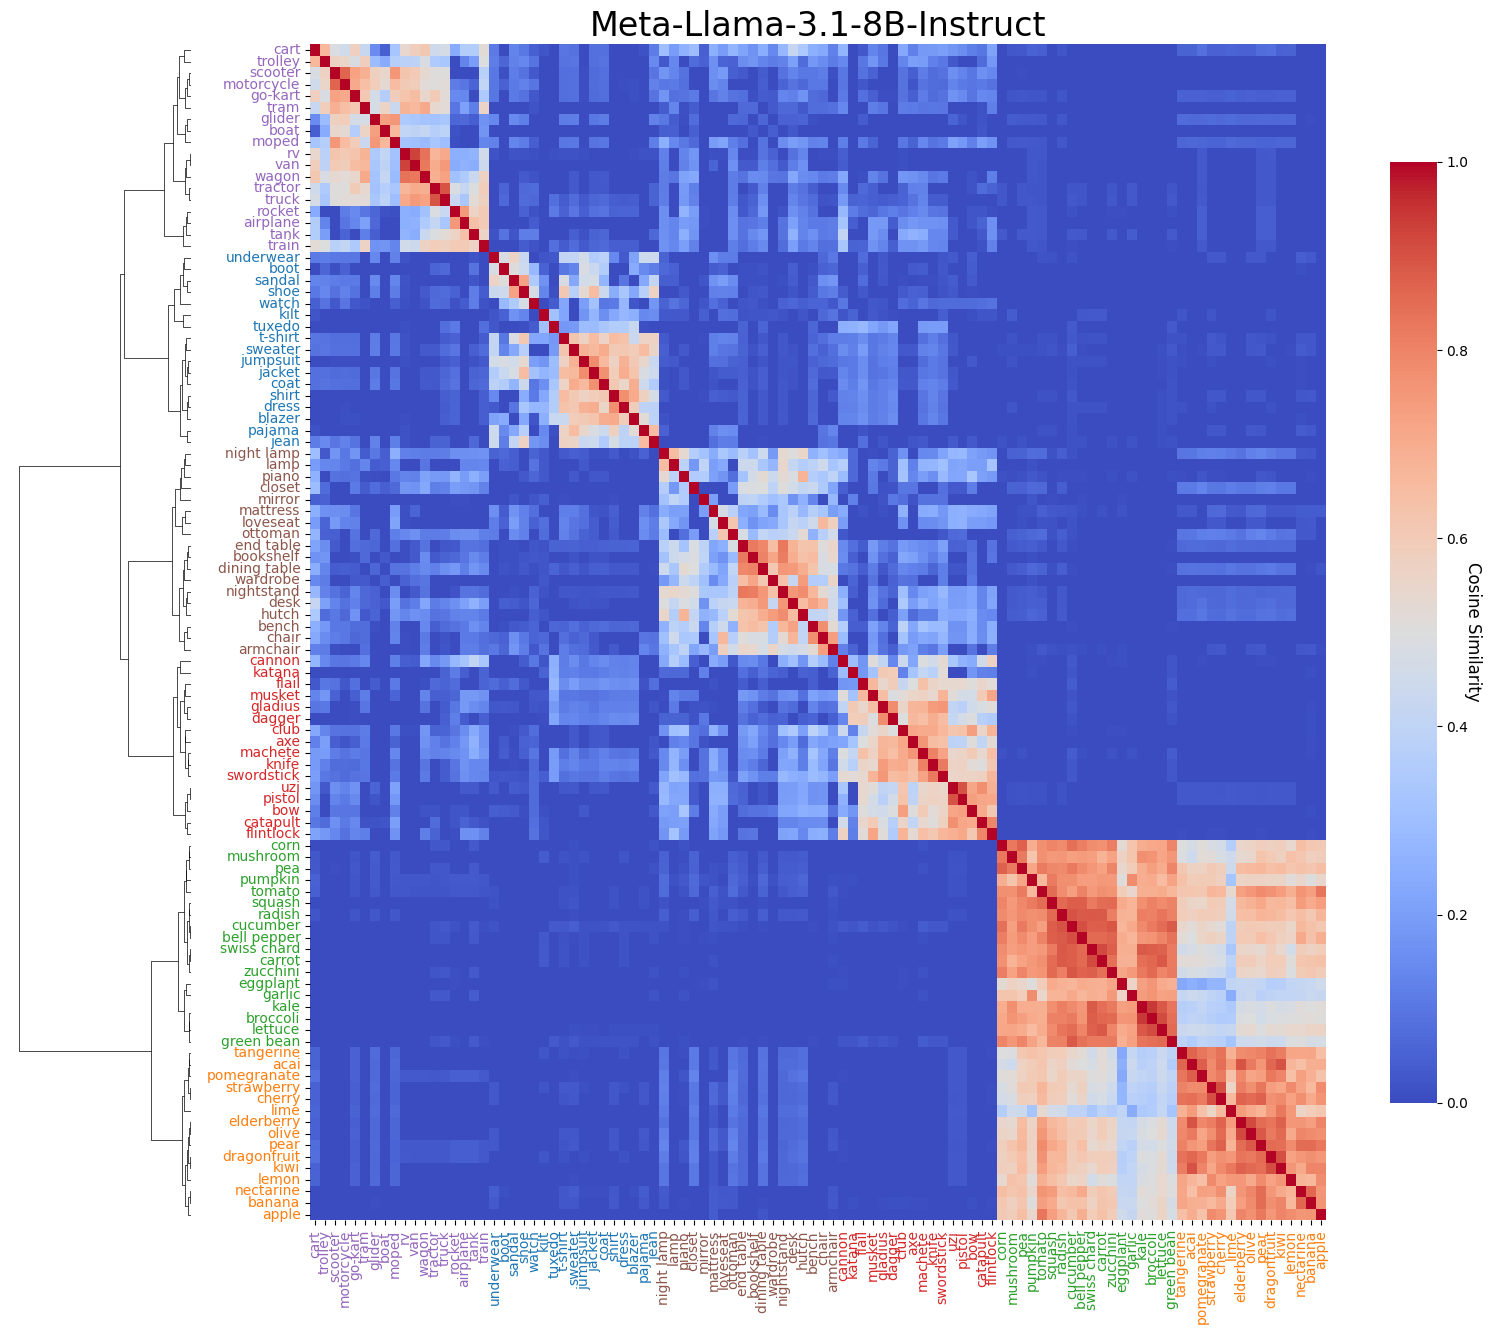

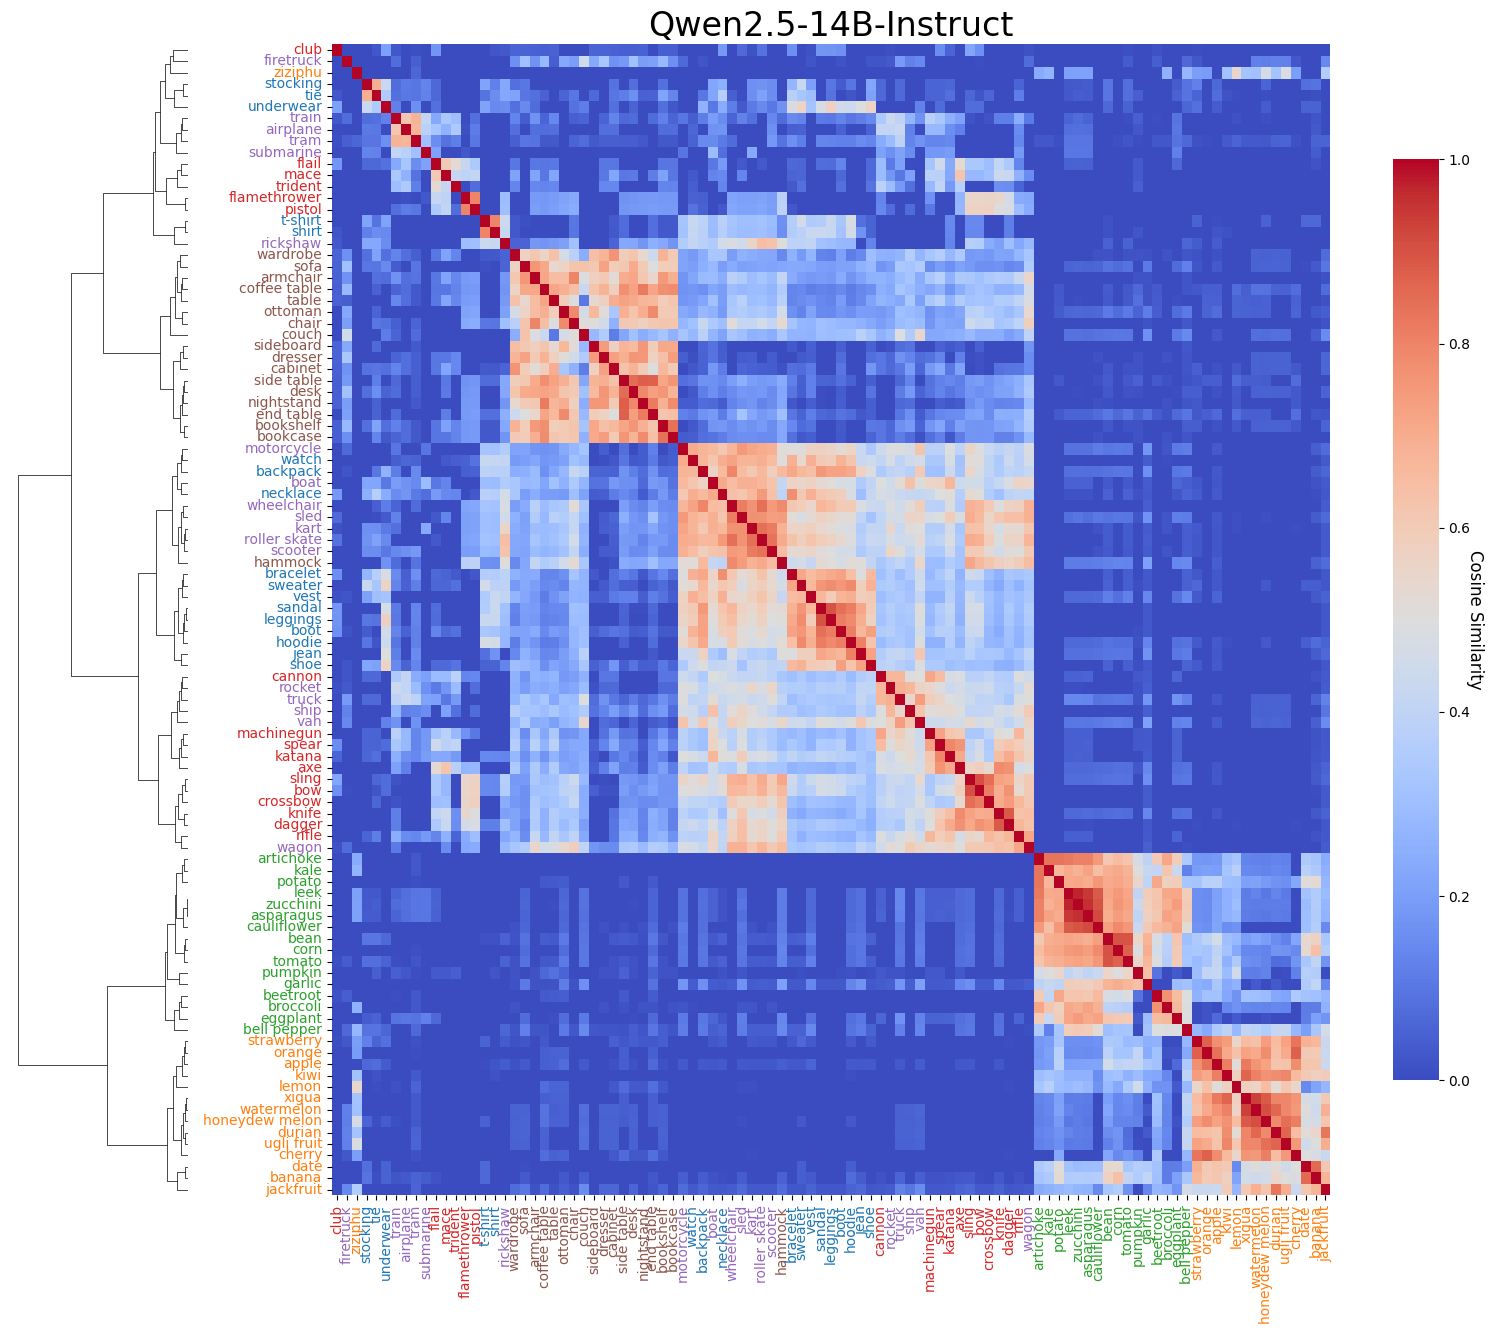

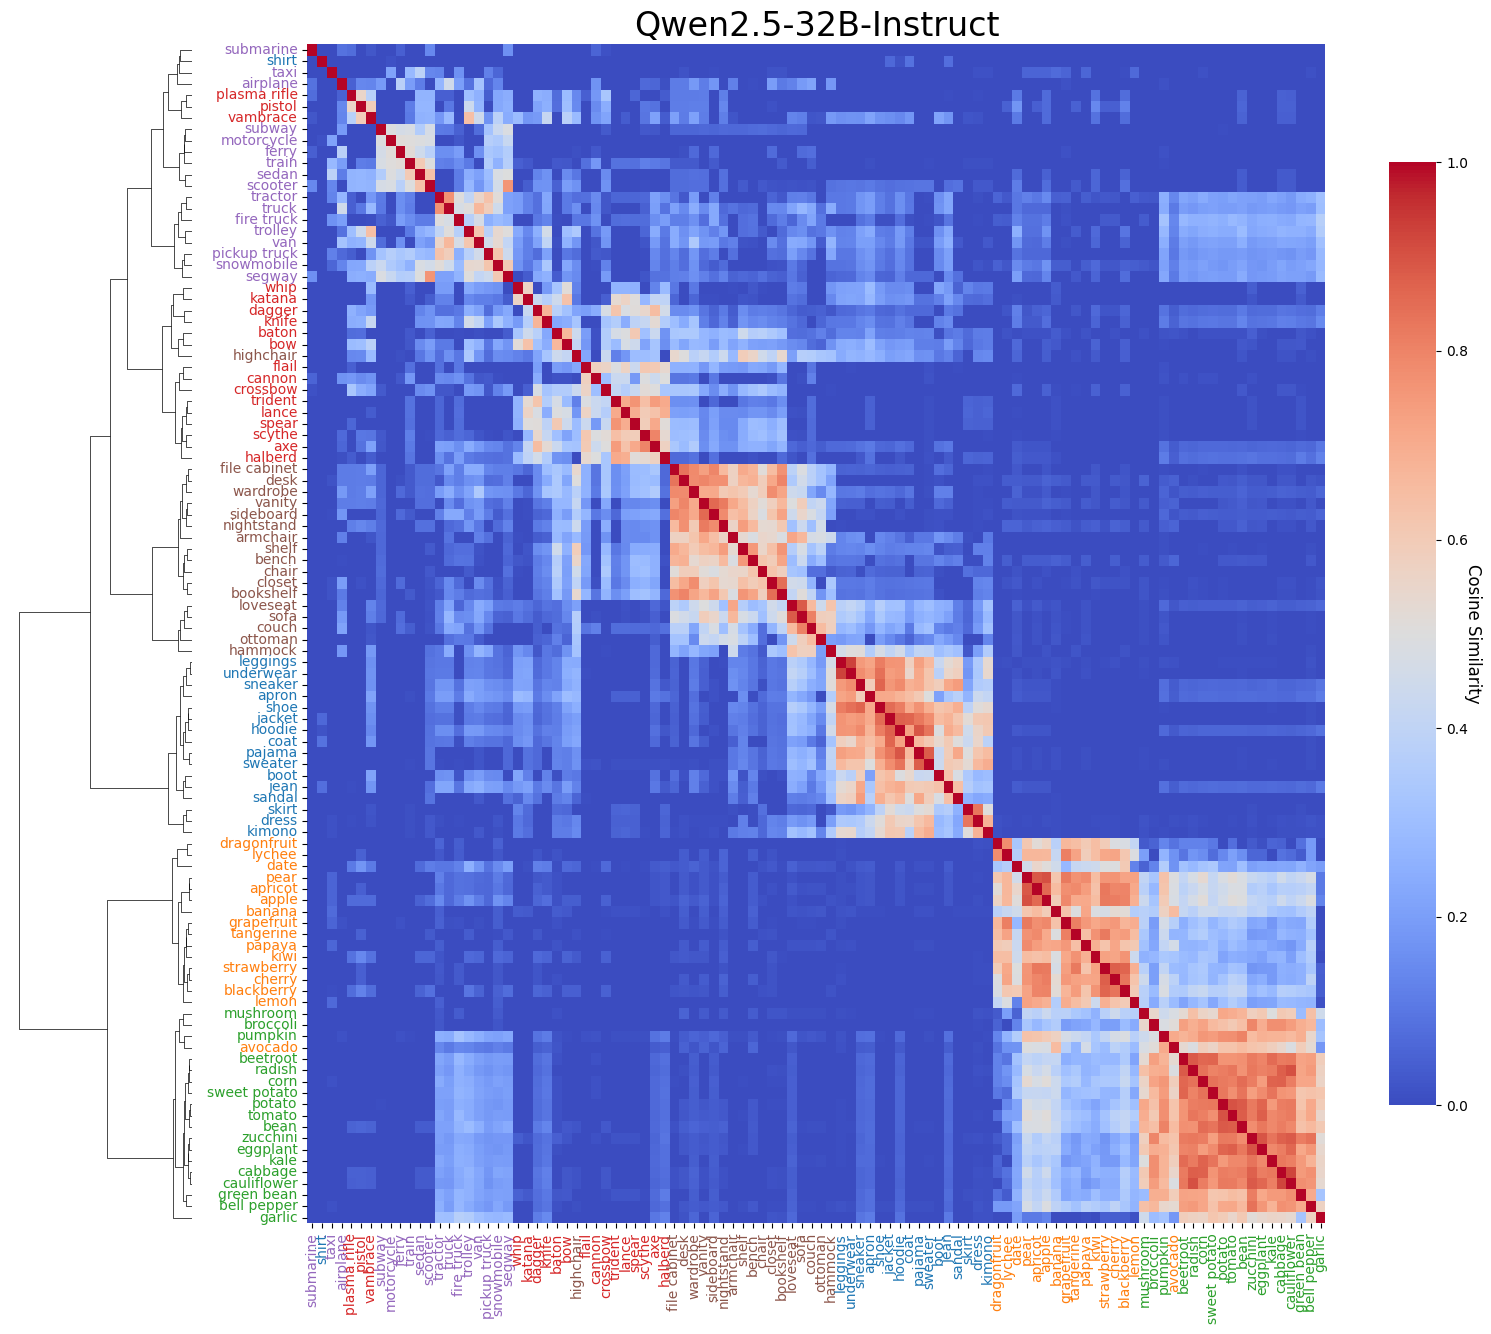

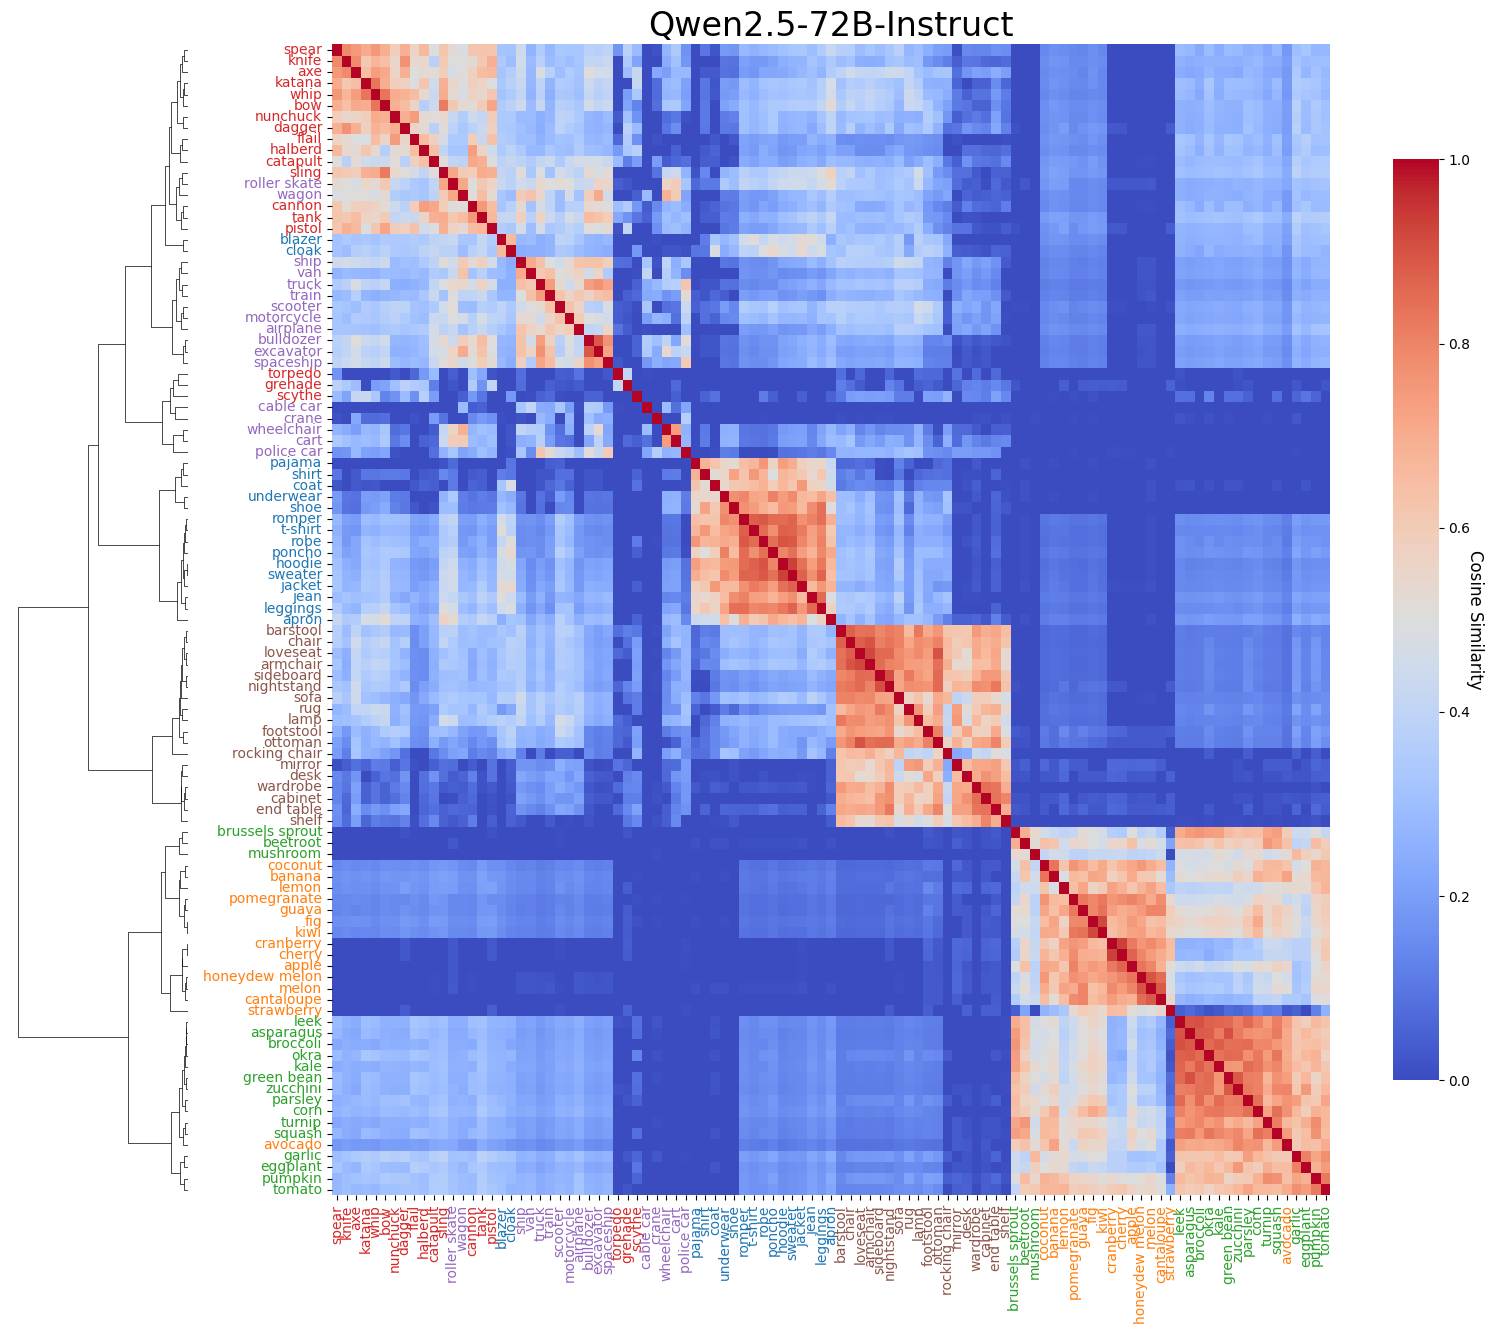

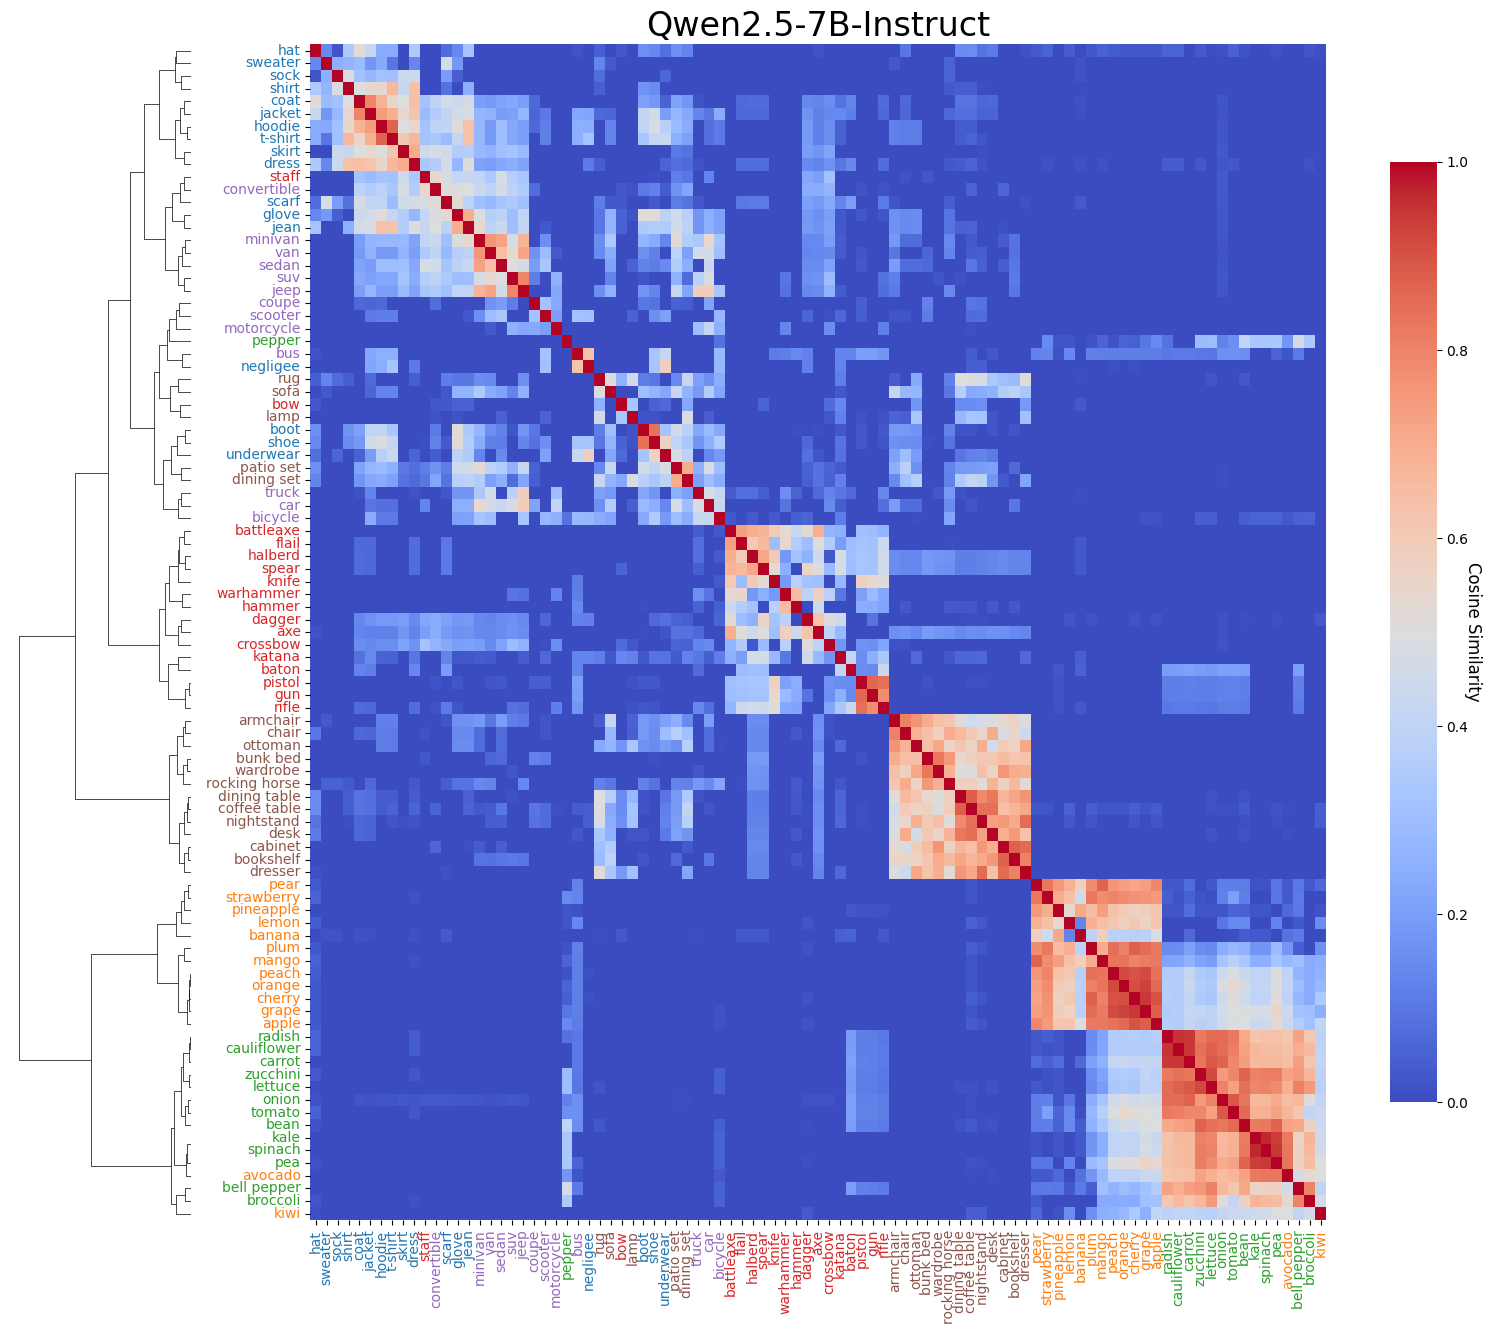

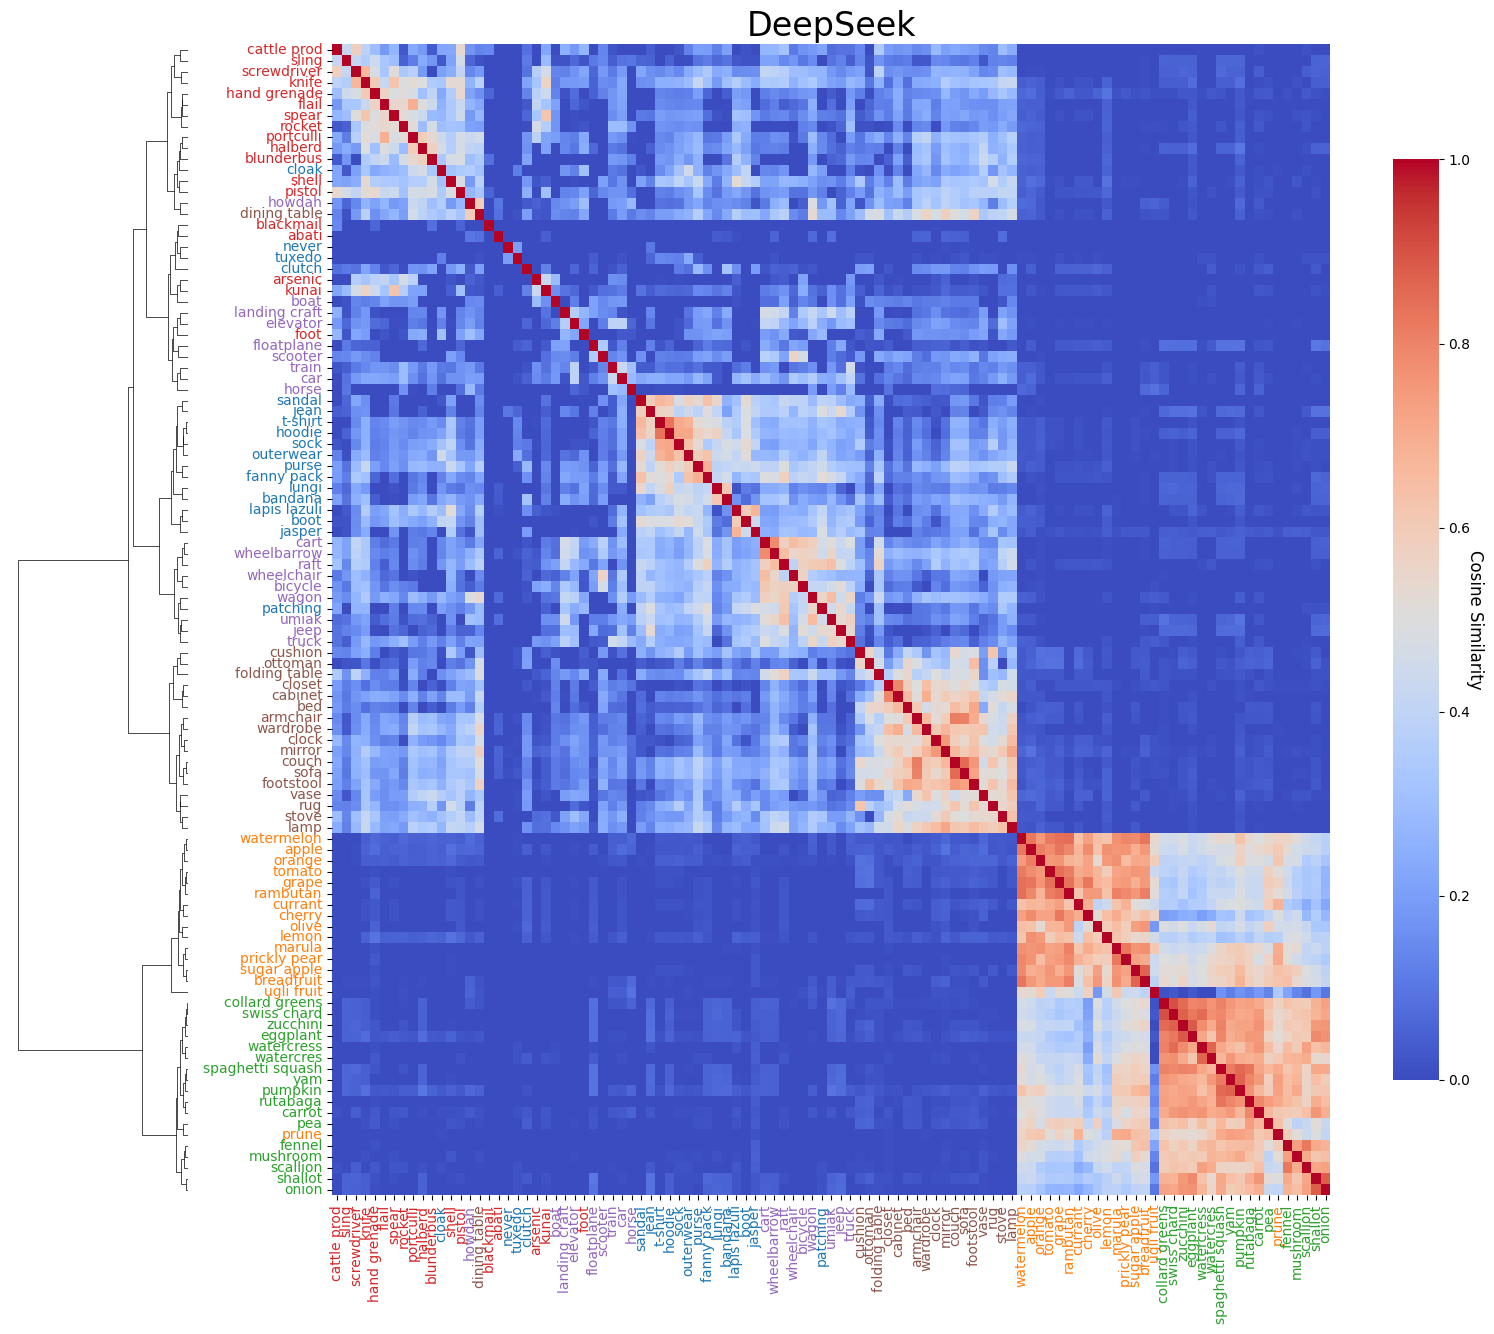

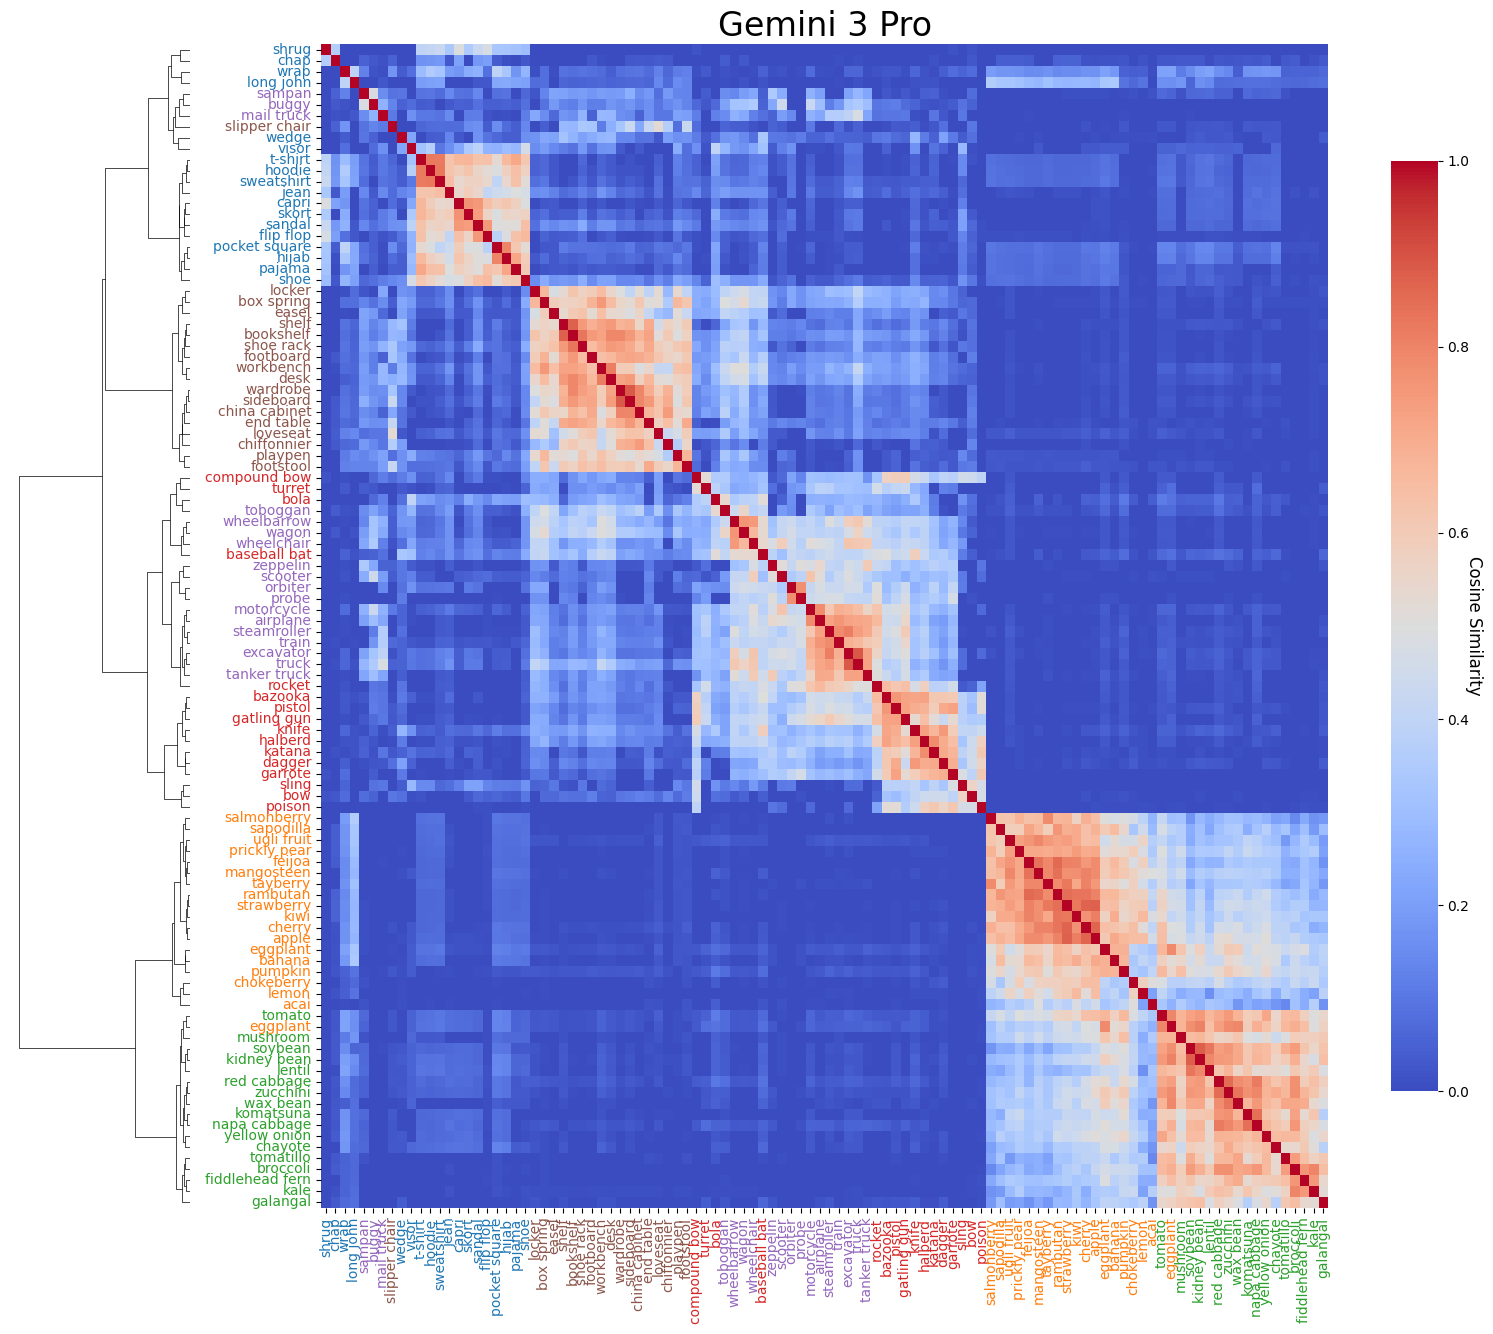

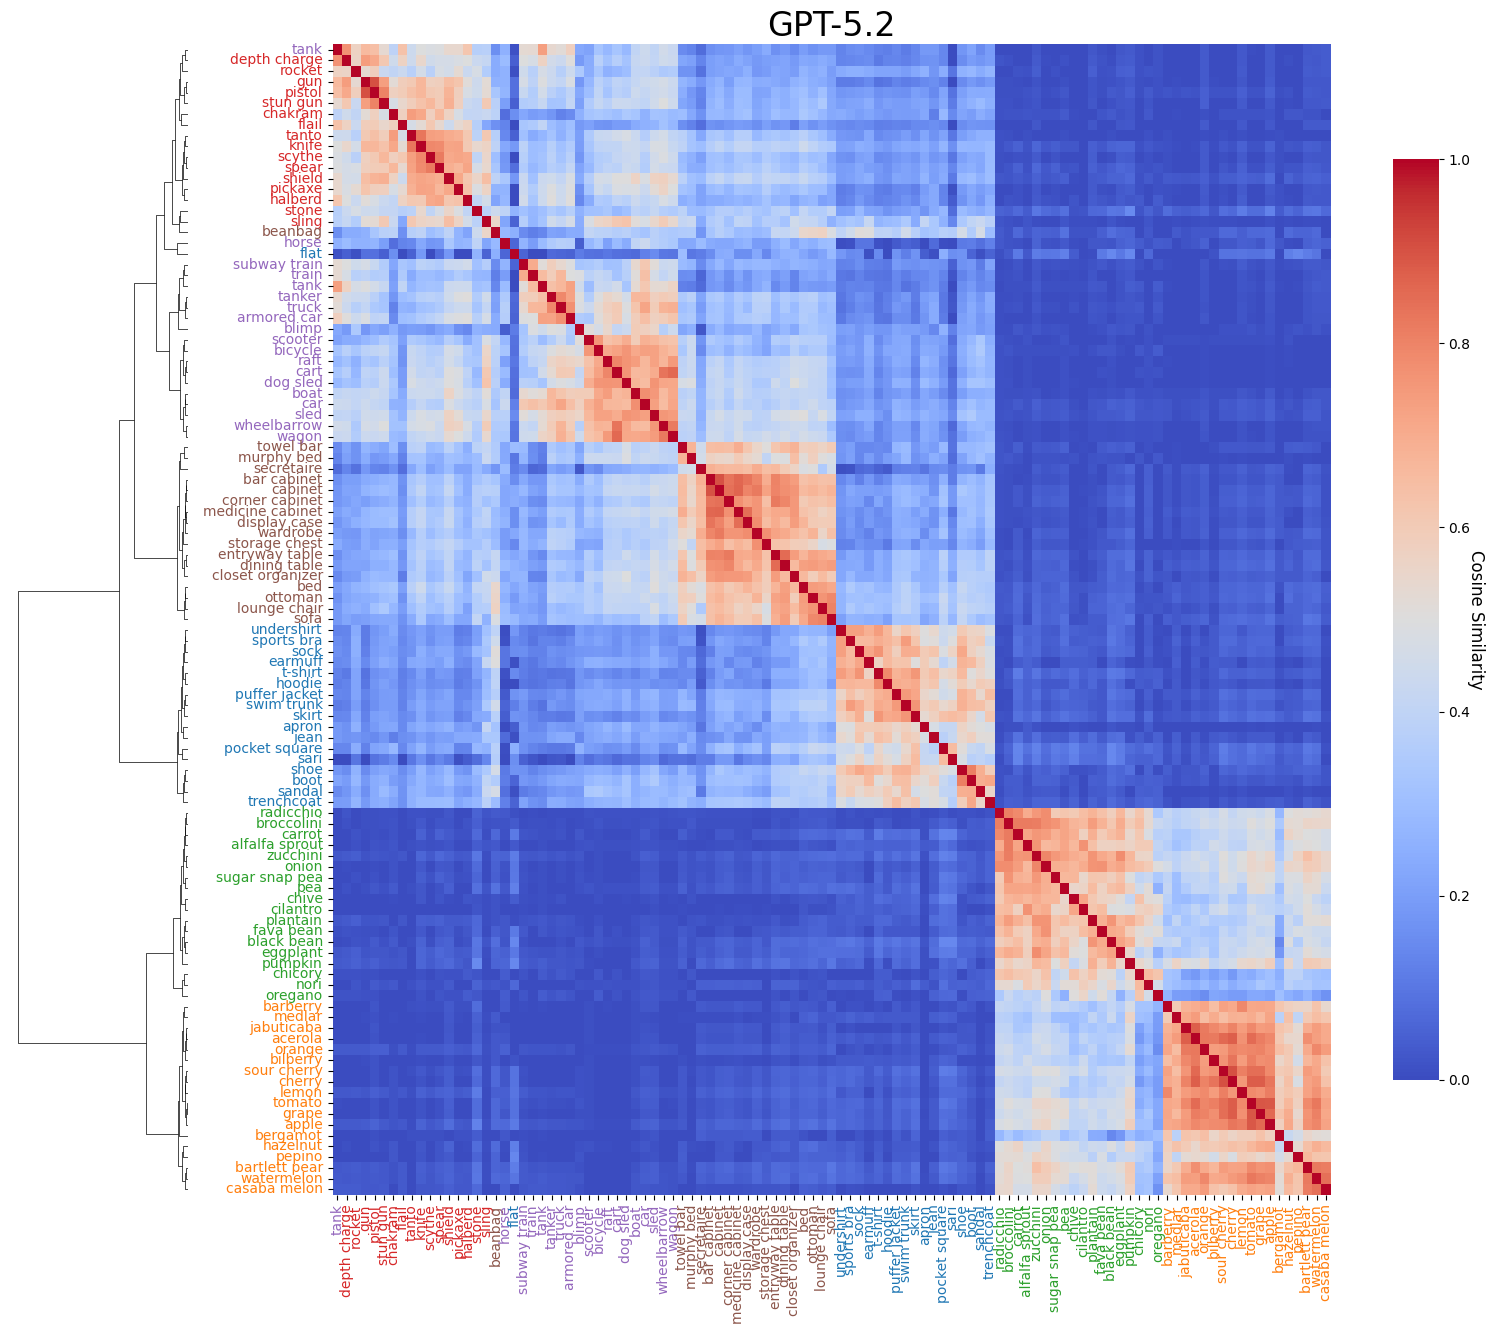

In [ ]:
# Heatmap and Dendrogram together

tab10 = get_cmap('tab10').colors
category_color_map = {
    'Vegetable': tab10[2],
    'Furniture': tab10[5],
    'Weapon': tab10[3],
    'Fruit': tab10[1],
    'Clothing': tab10[0],
    'Vehicle': tab10[4],
}

for model_name, similarity_matrix in cosine_similarity_matrices.items():
    model_df = sorted_df[sorted_df['model'] == model_name]

    if isinstance(similarity_matrix, np.ndarray):
        similarity_matrix = pd.DataFrame(similarity_matrix)

    distance_matrix = 1 - similarity_matrix.values

    linkage_matrix = linkage(distance_matrix, method='ward')

    sorted_items = model_df.sort_values(by=['category', 'frequency'], ascending=[True, False])

    fig = plt.figure(figsize=(16, 14))
    gs = GridSpec(1, 2, width_ratios=[1, 7])

    ax_dendro_row = fig.add_subplot(gs[:, 0])
    dn_row = dendrogram(
        linkage_matrix,
        ax=ax_dendro_row,
        orientation='left',
        labels=sorted_items['item'].values,
        leaf_rotation=0,
        leaf_font_size=12 
    )

    sorted_row_indices = leaves_list(linkage_matrix)[::-1]

    for line in ax_dendro_row.collections:
        line.set_edgecolor('black')
        line.set_linewidth(0.5)
    ax_dendro_row.set_title('', fontsize=12)
    ax_dendro_row.axis('off')

    ax_heatmap = fig.add_subplot(gs[0, 1])
    ordered_similarity_matrix = pd.DataFrame(
        similarity_matrix.values[sorted_row_indices, :][:, sorted_row_indices],
        index=sorted_items['item'].iloc[sorted_row_indices].values,
        columns=sorted_items['item'].iloc[sorted_row_indices].values
    )

    heatmap = sns.heatmap(
        ordered_similarity_matrix,
        ax=ax_heatmap,
        annot=False,
        cmap='coolwarm',
        xticklabels=True,
        yticklabels=True,
        cbar_kws={"shrink": 0.8}
    )

    colorbar = heatmap.collections[0].colorbar
    colorbar.set_label('Cosine Similarity', rotation=270, labelpad=10, fontsize=12)

    display_name_map = {
    'deepseek-chat': 'DeepSeek',
    'gemini-3-pro': 'Gemini 3 Pro',
    'gpt-5.2': 'GPT-5.2'
}
    display_name = display_name_map.get(model_name, model_name) 
    ax_heatmap.set_title(f'{display_name}', fontsize=24)

    for label in ax_heatmap.get_yticklabels():
        item = label.get_text()
        category = sorted_items.loc[sorted_items['item'] == item, 'category'].values[0]
        label.set_color(category_color_map.get(category, 'black'))
        label.set_fontsize(10)
    for label in ax_heatmap.get_xticklabels():
        item = label.get_text()
        category = sorted_items.loc[sorted_items['item'] == item, 'category'].values[0]
        label.set_color(category_color_map.get(category, 'black'))
        label.set_fontsize(10)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    filename = f'03_PropertiesFigures/figures_cosine_matrix_{model_name}.pdf'
    plt.savefig(filename, format='pdf', bbox_inches='tight')
    plt.show()

C:\Users\AS\AppData\Local\Temp\ipykernel_9524\4000510000.py:39: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  bar_plot = sns.barplot(data=correlation_df, x='category', y='correlation', hue='model', ci=None, alpha=1)


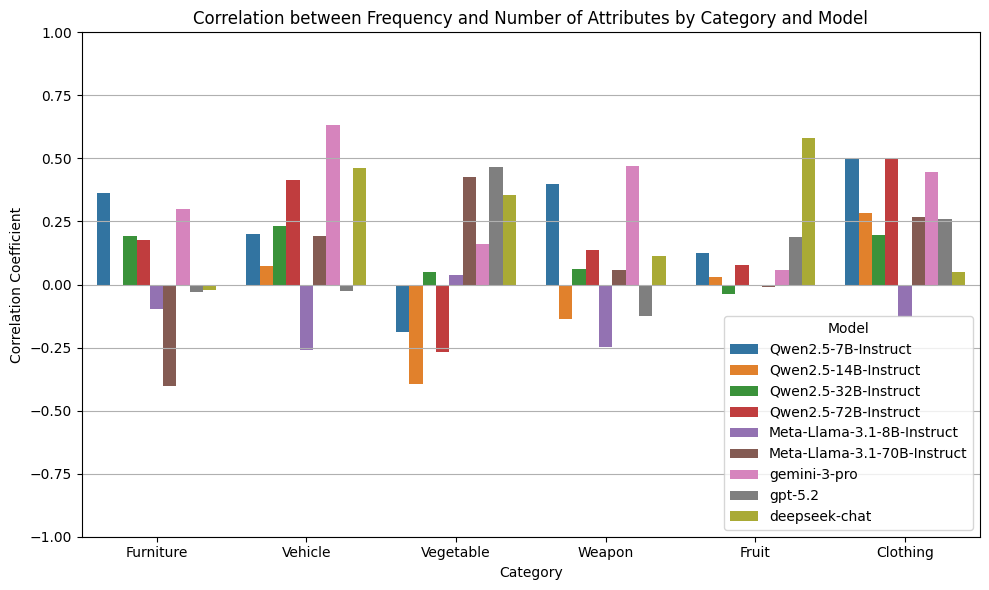

In [ ]:
# Plotting the number of attributes per item (to show that it is not mere matter of number of attributes)

unique_attributes_df['num_attributes'] = unique_attributes_df['attributes'].apply(len)

correlation_results = []

for model in unique_attributes_df['model'].unique():
    for category in unique_attributes_df['category'].unique():
        subset_df = unique_attributes_df[(unique_attributes_df['model'] == model) & 
                                          (unique_attributes_df['category'] == category)]
        if not subset_df.empty:
            correlation = subset_df['frequency'].corr(subset_df['num_attributes'])
            correlation_results.append({
                'model': model,
                'category': category,
                'correlation': correlation
            })

correlation_df = pd.DataFrame(correlation_results)

plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(data=correlation_df, x='category', y='correlation', hue='model', ci=None, alpha=1)

plt.ylim(-1, 1)

plt.title('Correlation between Frequency and Number of Attributes by Category and Model')
plt.xlabel('Category')
plt.ylabel('Correlation Coefficient')

plt.legend(title='Model', loc='lower right')

plt.grid(axis='y')
plt.tight_layout()

plt.show()


In [ ]:
# Within-between cosine difference for each caetgory and model

models = list(cosine_similarity_matrices.keys())
category_order = ['Vehicle', 'Weapon', 'Furniture', 'Clothing', 'Fruit', 'Vegetable']

num_categories = len(category_order)

n_rows = (len(models) + 1) // 2  

fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=(12, 6 * n_rows), sharex=True)

axes = axes.flatten()

for ax, model_name in zip(axes, models):
    
    similarity_matrix = cosine_similarity_matrices[model_name]

    if isinstance(similarity_matrix, np.ndarray):
        similarity_matrix = pd.DataFrame(similarity_matrix)

    model_df = sorted_df[sorted_df['model'] == model_name]

    all_plot_data = []

    for category_name in category_order:
        if category_name not in model_df['category'].unique():
            continue  

        category_items = model_df[model_df['category'] == category_name]['item'].values

        distance_matrix = 1 - similarity_matrix.values

        distance_df = pd.DataFrame(distance_matrix, index=model_df['item'].values, columns=model_df['item'].values)

        within_averages = []
        between_averages = []

        for item in category_items:
            
            within_distances = distance_df.loc[item, category_items].values
            within_average = np.mean(within_distances)
            within_averages.append(within_average)

            between_distances = distance_df.loc[item, distance_df.columns.difference(category_items)].values
            between_average = np.mean(between_distances)
            between_averages.append(between_average)

        final_values = np.array(within_averages) - np.array(between_averages)

        category_plot_data = pd.DataFrame({
            'Category': [category_name] * len(final_values),
            'Distance': final_values
        })

        all_plot_data.append(category_plot_data)

    final_plot_data = pd.concat(all_plot_data, ignore_index=True)

    final_plot_data['Category'] = pd.Categorical(final_plot_data['Category'], categories=category_order, ordered=True)

    sns.boxplot(data=final_plot_data, x='Category', y='Distance', palette='coolwarm', ax=ax)

    ax.set_title(f'{model_name}', fontsize=14)
    ax.set_ylabel('Within-Between Similarity Distance', fontsize=12)

plt.xlabel('Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


C:\Users\AS\AppData\Local\Temp\ipykernel_9524\55698493.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = get_cmap('tab10').colors
C:\Users\AS\AppData\Local\Temp\ipykernel_9524\55698493.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\AS\AppData\Local\Temp\ipykernel_9524\55698493.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\AS\AppData\Local\Temp\ipykernel_9524\55698493.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.1

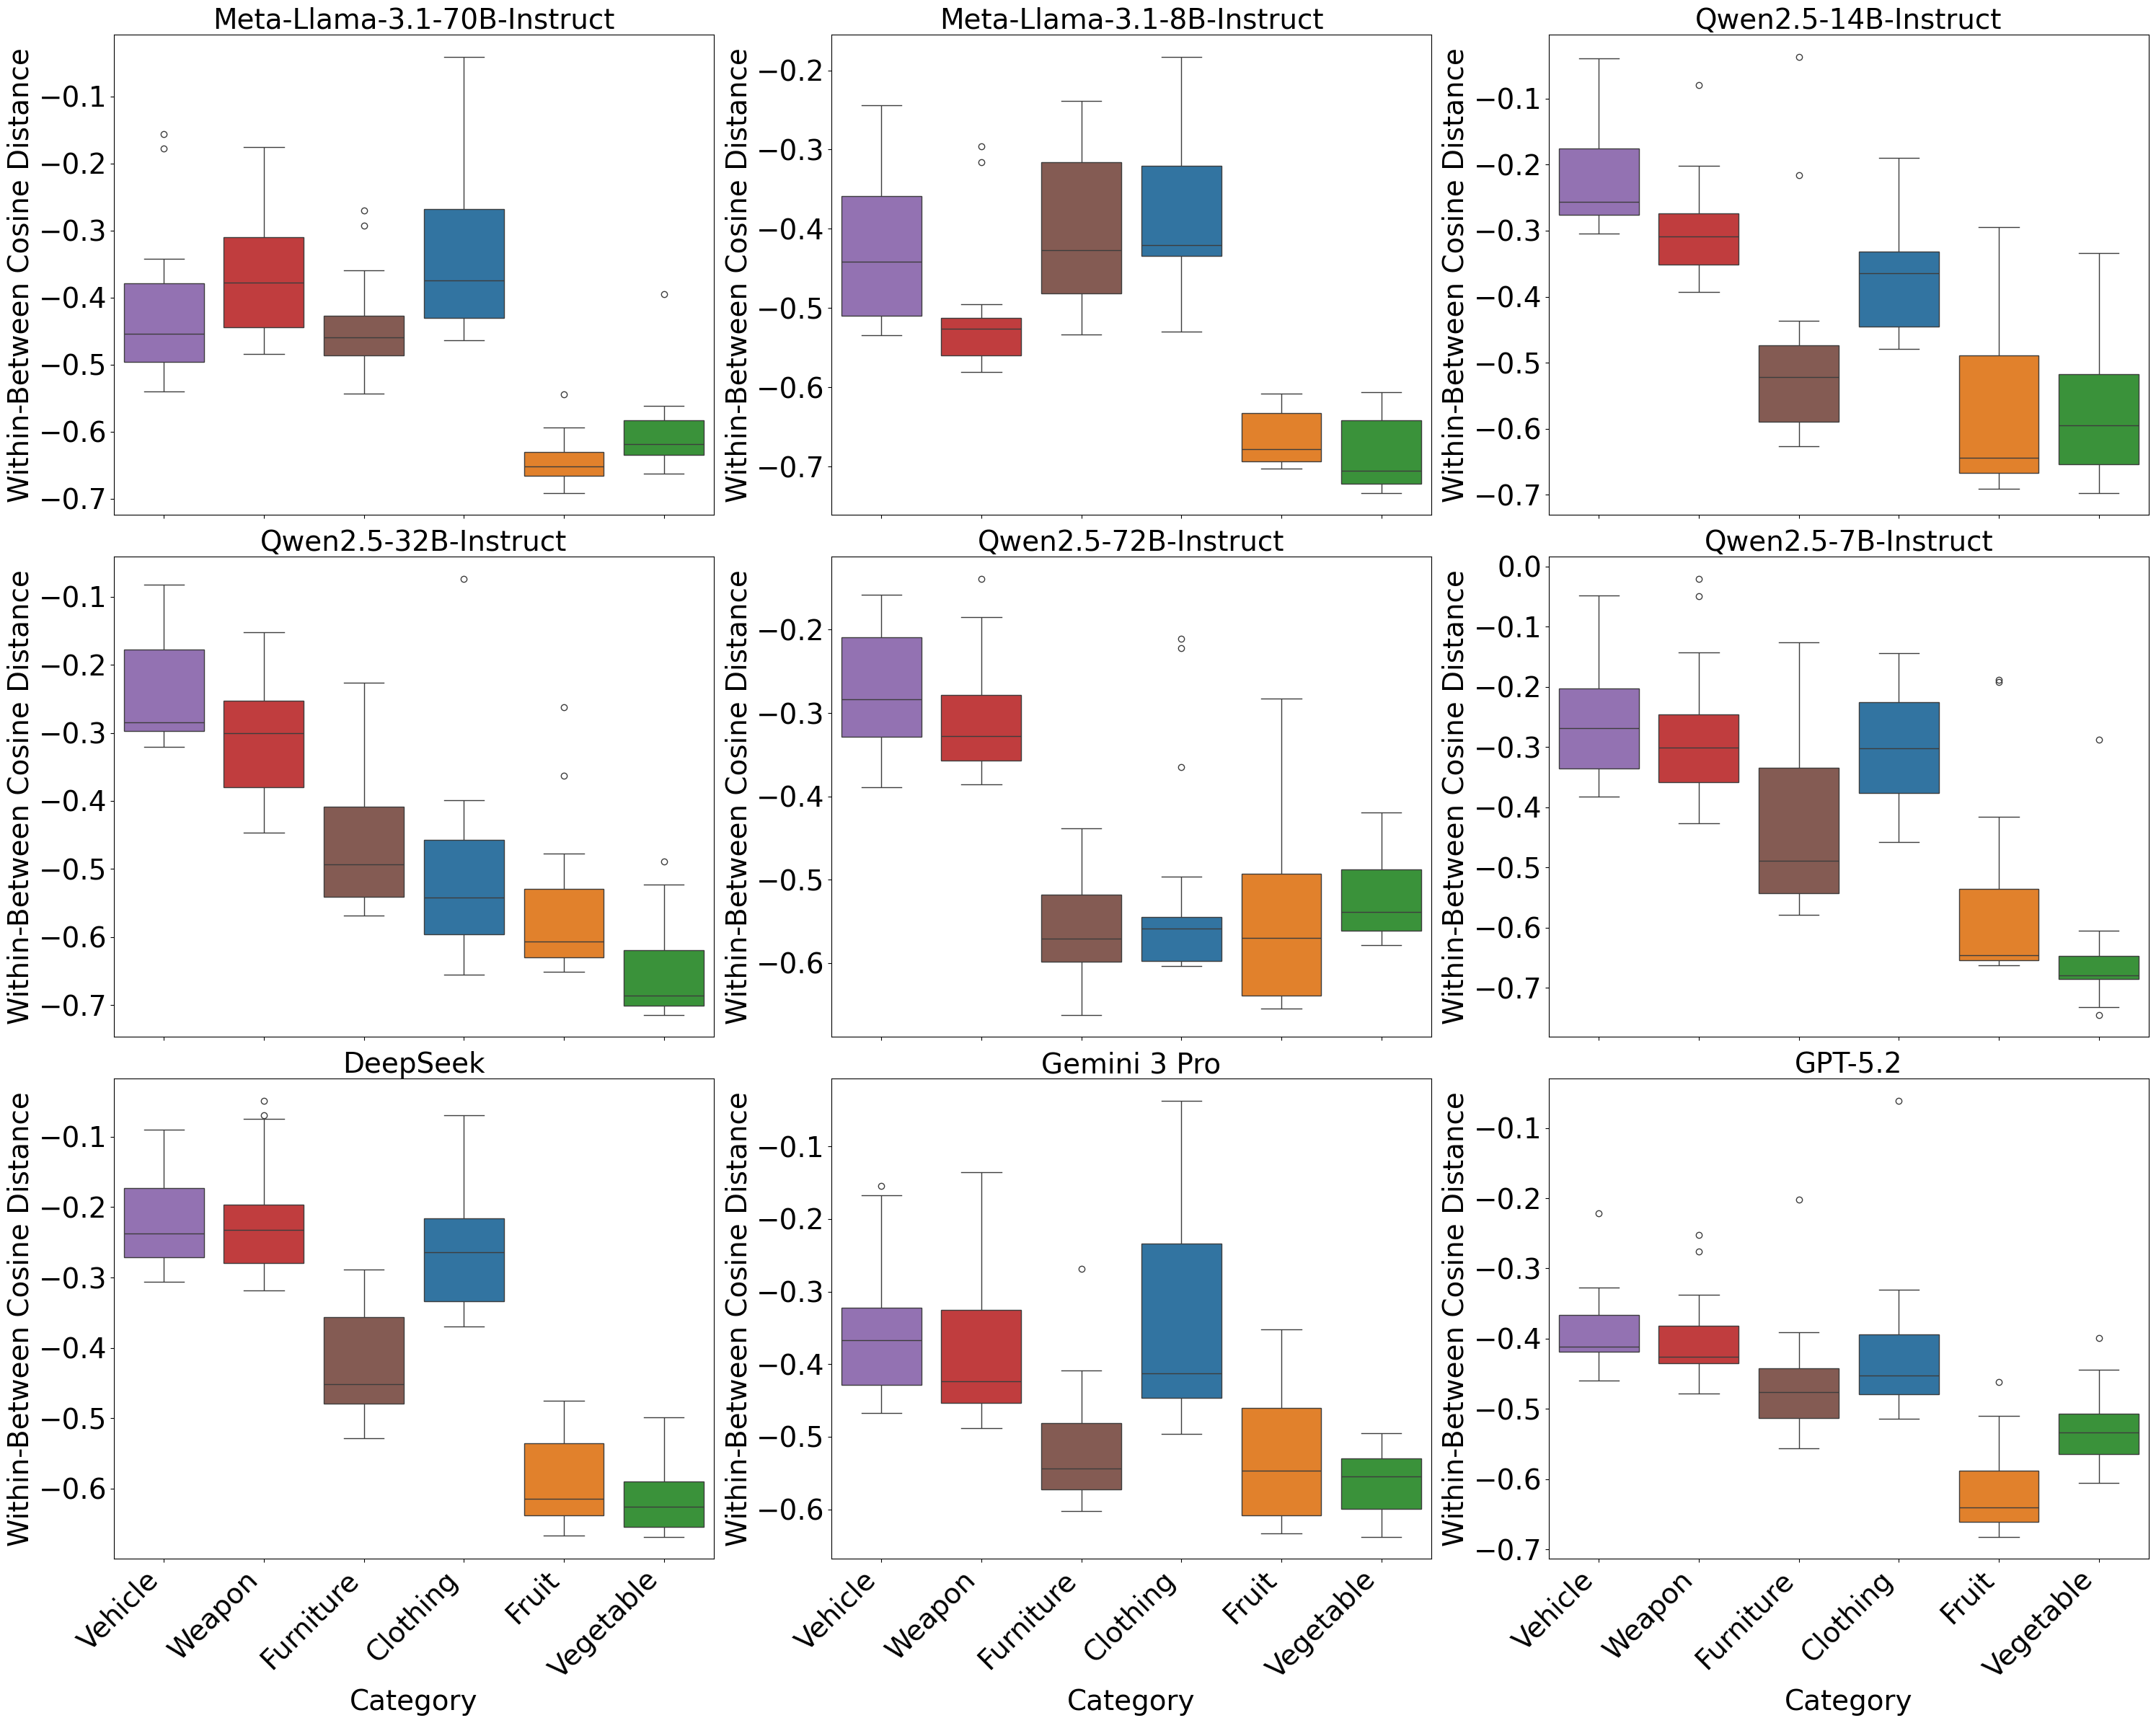

In [ ]:
tab10 = plt.get_cmap('tab10').colors

category_order = ['Vehicle', 'Weapon', 'Furniture', 'Clothing', 'Fruit', 'Vegetable']

tab10 = get_cmap('tab10').colors
category_color_map = {
    'Vegetable': tab10[2],
    'Furniture': tab10[5],
    'Weapon': tab10[3],
    'Fruit': tab10[1],
    'Clothing': tab10[0],
    'Vehicle': tab10[4],
}

remaining_categories = [c for c in category_order if c not in category_color_map]
unused_indices = [i for i in range(10) if i not in [2, 3, 5]]
unused_colors = [tab10[i] for i in unused_indices]

for cat, col in zip(remaining_categories, unused_colors):
    category_color_map[cat] = col

colors = [category_color_map[cat] for cat in category_order]

models = list(cosine_similarity_matrices.keys())
n_cols = 3
n_rows = (len(models) + n_cols - 1) // n_cols

display_names = []
for model_name in models:
    if model_name == 'deepseek-chat':
        display_names.append('DeepSeek')
    elif model_name == 'gemini-3-pro':
        display_names.append('Gemini 3 Pro')
    elif model_name == 'gpt-5.2':
        display_names.append('GPT-5.2')
    else:
        display_names.append(model_name)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10 * n_cols, 8 * n_rows))
axes = axes.flatten()

for i, (ax, model_name) in enumerate(zip(axes, models)):
    similarity_matrix = cosine_similarity_matrices[model_name]
    if isinstance(similarity_matrix, np.ndarray):
        similarity_matrix = pd.DataFrame(similarity_matrix)

    model_df = sorted_df[sorted_df['model'] == model_name]
    all_plot_data = []

    for category_name in category_order:
        if category_name not in model_df['category'].unique():
            continue

        category_items = model_df[model_df['category'] == category_name]['item'].values
        distance_matrix = 1 - similarity_matrix.values
        distance_df = pd.DataFrame(distance_matrix, index=model_df['item'].values, columns=model_df['item'].values)

        within_averages, between_averages = [], []

        for item in category_items:
            within_averages.append(np.mean(distance_df.loc[item, category_items].values))
            between_averages.append(np.mean(distance_df.loc[item, distance_df.columns.difference(category_items)].values))

        final_values = np.array(within_averages) - np.array(between_averages)
        category_plot_data = pd.DataFrame({'Category': [category_name] * len(final_values), 'Distance': final_values})
        all_plot_data.append(category_plot_data)

    final_plot_data = pd.concat(all_plot_data, ignore_index=True)
    final_plot_data['Category'] = pd.Categorical(final_plot_data['Category'], categories=category_order, ordered=True)

    sns.boxplot(
        data=final_plot_data,
        x='Category',
        y='Distance',
        palette=colors,
        ax=ax
    )
    ax.set_title(f'{display_names[i]}', fontsize=28)
    ax.set_ylabel('Within-Between Cosine Distance', fontsize=28)
    ax.tick_params(axis='y', labelsize=28)

    if i >= len(axes) - n_cols:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=28)
        ax.set_xlabel('Category', fontsize=28)
    else:
        ax.set_xticklabels([])
        ax.set_xlabel('')

for i in range(len(models), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("03_PropertiesFigures/figure_within-between_distance.pdf", format='pdf', bbox_inches='tight')
plt.show()